<div style="background:linear-gradient(135deg,#083344 0%,#0e7490 55%,#06b6d4 100%);border-radius:18px;padding:34px 30px;color:#fff;font-family:Inter,Segoe UI,sans-serif">
  <div style="font-size:12px;letter-spacing:3px;color:#a5f3fc;font-weight:700;text-transform:uppercase">Chapter 85 · Case Study · Inference</div>
  <div style="font-size:33px;font-weight:900;line-height:1.1;margin:10px 0 6px">Case Study: Comparing Marketing Channels 📣</div>
  <div style="font-size:15px;color:#ecfeff;max-width:760px;line-height:1.6">Four acquisition channels, one numeric outcome, and a budget on the line. We explore the data, then let statsmodels run the ANOVA and Tukey HSD, no hand-coded post-hoc loop, and cross-check with a rank-based test.</div>
  <div style="margin-top:16px;font-size:13px;color:#a5f3fc">Statistics, Data Science and AI: A Visual Handbook · John Fisher · 2026</div>
</div>

## ⚙️ Setup

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from scipy import stats
# statsmodels = the R/SAS-style stats library (pre-installed on Colab): it does the standard errors,
# test statistics, intervals, and post-hoc comparisons for us, so we write far less by-hand code.
import statsmodels.api as sm
from statsmodels.formula.api import ols
from statsmodels.stats.proportion import proportions_ztest, confint_proportions_2indep, proportion_confint
from statsmodels.stats.multicomp import pairwise_tukeyhsd
from statsmodels.stats.weightstats import DescrStatsW, CompareMeans
from scipy.stats.contingency import association   # Cramer's V in one call
CY="#0891b2"; DEEP="#0e7490"; LIGHT="#67e8f9"; INK="#1a2138"; GRID="#e6e9f2"; GREEN="#059669"; RED="#ef4444"; AMBER="#d97706"
plt.rcParams.update({"figure.facecolor":"white","axes.facecolor":"white","figure.dpi":110,"font.size":11,
   "axes.edgecolor":GRID,"axes.grid":True,"grid.color":GRID,"axes.axisbelow":True,"axes.spines.top":False,
   "axes.spines.right":False,"axes.titlesize":12,"axes.titleweight":"bold","legend.frameon":False})
pd.set_option("display.width",120)
BASE="https://raw.githubusercontent.com/johnfisher-ai/Statistics-Data-Science-AI-Visual-Book/main/data/"
rng = np.random.default_rng(85)

<div style="background:#ecfeff;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0e7490;letter-spacing:1px">STEP 1 · EXPLORE THE DATA</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">Summaries and shape, per channel, before any test</div>
<div style="color:#4a5578;margin-top:6px">First get a feel: how big is each channel group, what does revenue look like, is it skewed, are there outliers? A right-skewed revenue distribution would steer us toward a rank-based cross-check, so we look before we leap.</div>
</div>

In [2]:
try:    d = pd.read_excel("../../data/ch85_marketing_channels.xlsx", sheet_name="Customers")
except FileNotFoundError: d = pd.read_excel(BASE+"ch85_marketing_channels.xlsx", sheet_name="Customers")
print("shape:", d.shape, "| missing:", d.isna().sum().sum())
summ = d.groupby("channel").revenue_per_customer.agg(["size","mean","std","median",
          ("skew", lambda s: stats.skew(s))]).round(1)
print(summ.sort_values("mean", ascending=False))

shape: (280, 4) | missing: 0
             size  mean   std  median  skew
channel                                    
Email          70  92.2  29.8    92.0  -0.1
Organic        70  77.6  24.8    78.9  -0.0
Paid Search    70  69.9  25.6    71.6   0.2
Social         70  67.3  25.7    69.8  -0.2


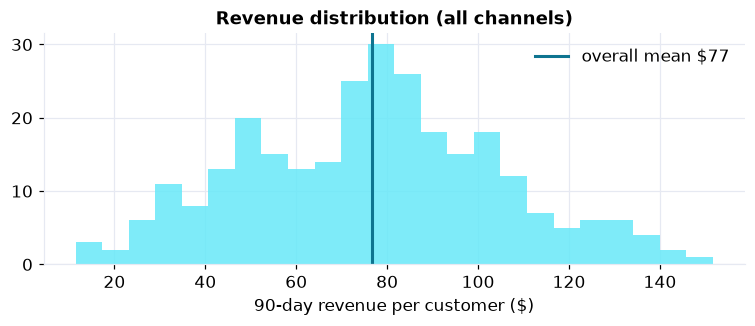

In [3]:
fig,ax=plt.subplots(figsize=(7,3.1))
ax.hist(d.revenue_per_customer, bins=24, color=LIGHT, alpha=0.85)
ax.axvline(d.revenue_per_customer.mean(), color=DEEP, lw=2, label=f"overall mean ${d.revenue_per_customer.mean():.0f}")
ax.set_xlabel("90-day revenue per customer ($)"); ax.set_title("Revenue distribution (all channels)"); ax.legend()
plt.tight_layout(); plt.show()

The groups are balanced (about 70 each), revenue is only mildly skewed, and Email has the highest average. ANOVA&#39;s conditions look fine, and we will still cross-check with a rank-based test because revenue can have a tail.

<div style="background:#ecfeff;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0e7490;letter-spacing:1px">STEP 2 · CHOOSE THE TEST & STATE THE HYPOTHESES</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">A numeric outcome across four groups</div>
<div style="color:#4a5578;margin-top:6px">Numeric outcome, FOUR independent groups. Six pairwise t-tests would inflate the false-alarm rate, so we use ONE-WAY ANOVA as the omnibus test, with Tukey HSD as the post-hoc to find which channels differ.</div>
</div>

In [4]:
print("Decision: numeric outcome + 4 independent groups -> ONE-WAY ANOVA (+ Tukey HSD)")
print("H0: mu_Organic = mu_Paid = mu_Email = mu_Social  (all channels equal)")
print("H1: at least one channel mean differs")

Decision: numeric outcome + 4 independent groups -> ONE-WAY ANOVA (+ Tukey HSD)
H0: mu_Organic = mu_Paid = mu_Email = mu_Social  (all channels equal)
H1: at least one channel mean differs


<div style="background:#ecfeff;border-left:5px solid #0891b2;border-radius:10px;padding:16px 20px;font-family:Inter,sans-serif">
<span style="font-size:13px;font-weight:800;color:#0e7490;letter-spacing:1px">STEP 3 · RUN THE ANALYSIS</span>
<div style="font-size:21px;font-weight:800;color:#1a2138;margin-top:4px">statsmodels: one ANOVA table, one Tukey call</div>
<div style="color:#4a5578;margin-top:6px">We fit the model with a formula (just like R: revenue ~ channel), read the ANOVA table from statsmodels, compute eta-squared from its sums of squares, cross-check with Kruskal-Wallis, and get every pairwise comparison from pairwise_tukeyhsd, no hand-coded loops.</div>
</div>

In [5]:
model = ols("revenue_per_customer ~ C(channel)", data=d).fit()
aov = sm.stats.anova_lm(model, typ=2)
eta2 = aov.loc["C(channel)","sum_sq"] / aov["sum_sq"].sum()
print(aov.round(3))
print(f"\neta^2 = {eta2:.3f} (channel explains ~{eta2*100:.0f}% of revenue variation)")
groups=[g.revenue_per_customer.values for _,g in d.groupby("channel")]
print(f"Kruskal-Wallis cross-check: H={stats.kruskal(*groups).statistic:.2f}, p={stats.kruskal(*groups).pvalue:.2e} (agrees)")

                sum_sq     df      F  PR(>F)
C(channel)   26362.164    3.0  12.44     0.0
Residual    194955.764  276.0    NaN     NaN

eta^2 = 0.119 (channel explains ~12% of revenue variation)
Kruskal-Wallis cross-check: H=29.72, p=1.58e-06 (agrees)


      Multiple Comparison of Means - Tukey HSD, FWER=0.05       
   group1      group2   meandiff p-adj   lower    upper   reject
----------------------------------------------------------------
      Email     Organic -14.6054  0.007 -26.2172  -2.9937   True
      Email Paid Search -22.3427    0.0 -33.9545  -10.731   True
      Email      Social -24.9199    0.0 -36.5316 -13.3081   True
    Organic Paid Search  -7.7373  0.314  -19.349   3.8745  False
    Organic      Social -10.3144 0.1014 -21.9262   1.2973  False
Paid Search      Social  -2.5771 0.9399 -14.1889   9.0346  False
----------------------------------------------------------------


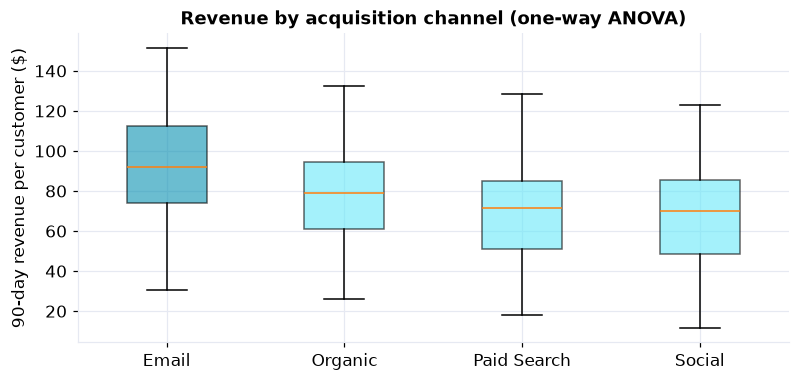

In [6]:
# Tukey HSD: one function call replaces the whole pairwise loop
tukey = pairwise_tukeyhsd(d.revenue_per_customer, d.channel)
print(tukey.summary())
fig,ax=plt.subplots(figsize=(7.4,3.6))
order=d.groupby("channel").revenue_per_customer.mean().sort_values(ascending=False).index.tolist()
bp=ax.boxplot([d[d.channel==c].revenue_per_customer.values for c in order], tick_labels=order, patch_artist=True)
for patch,c in zip(bp["boxes"],[CY,LIGHT,LIGHT,LIGHT]): patch.set_facecolor(c); patch.set_alpha(0.6)
ax.set_ylabel("90-day revenue per customer ($)"); ax.set_title("Revenue by acquisition channel (one-way ANOVA)")
plt.tight_layout(); plt.show()

The ANOVA table is decisive (F &#8776; 12.4, p &#8776; 10&#8315;&#8311;), channel explains about <strong>12%</strong> of revenue variation, and Kruskal-Wallis agrees. The Tukey table tells the whole story in one glance: <strong>Email</strong> differs significantly from each of the other three (reject = True), while Organic, Paid Search, and Social do not differ from one another (reject = False).

<div style="background:#ffffff;border:1px solid #cffafe;border-left:5px solid #0e7490;border-radius:12px;padding:18px 22px;font-family:Inter,sans-serif">
<div style="font-size:12px;font-weight:800;color:#0e7490;letter-spacing:1px">📋 STATISTICIAN’S REPORT</div>
<div style="font-size:18px;font-weight:800;color:#1a2138;margin:4px 0 8px">Recommendation: shift budget toward Email</div>
<div style="color:#3f4a63;line-height:1.75"><strong>What we found.</strong> Customers acquired through <strong>Email</strong> are worth about <strong>$92</strong> in their first 90 days, roughly <strong>$15 to $25 more</strong> than those from Organic ($78), Paid Search ($70), or Social ($67). The other three channels are statistically about the same as each other. <br><br><strong>How confident are we?</strong> The overall difference is extremely unlikely to be chance (p &#8776; 0.0000001), and a rank-based method agrees, so it does not depend on assuming a perfect bell curve. The Tukey comparison (which corrects for testing several pairs) confirms Email stands apart from all three others. <br><br><strong>What to do.</strong> Re-weight acquisition spend toward Email; treat Organic, Paid, and Social as interchangeable on revenue for now. <br><br><strong>Caveats.</strong> This is revenue <em>per acquired customer</em>, not per dollar spent, fold in each channel&#39;s acquisition cost before finalizing budget. And because channels were not randomly assigned (observational data), some of Email&#39;s edge could reflect who self-selects into it.</div>
</div>

---
<div style="text-align:center;color:#8b94b3;font-size:12px;margin-top:10px">Statistics, Data Science and AI: A Visual Handbook · © 2026 John Fisher</div>